In [136]:
# # --- environment setup (added for the JAX backend) ---
# import os, sys
# os.environ["JAX_PLATFORMS"] = "cpu"            # this machine's METAL backend is broken
# repo_root = os.path.abspath("..")              # notebooks/ -> AnniesLasso repo root
# if repo_root not in sys.path:
#     sys.path.insert(0, repo_root)              # ensure the edited working tree is imported

import jax
jax.config.update("jax_platform_name", "cuda")

import thecannon as tc
print("thecannon:", tc.__file__)

thecannon: /scratch/mk27/mj8805/AnniesLasso/thecannon/__init__.py


Evo_state; kepler: rgb: 1, heb=2

In [137]:
import os
import numpy as np
import thecannon as tc
import matplotlib.pyplot as plt
import matplotlib
%matplotlib inline

from thecannon import continuum

In [138]:
import pandas as pd
from pathlib import Path
SRC = Path("/home/100/mj8805/scr_mk27/")

In [139]:
spectra = pd.read_parquet(SRC / "bulge-ages-and-orbits/data/merged_with_ages_raw.parquet")

In [140]:
spectra = spectra[(spectra['flag_bad'] == 0)]
spectra = spectra[spectra['RelAge_Dnu'] == 0]
spectra = spectra[spectra['spectrum_flags_x'] == 0]
len(spectra)

5010

Training-set cuts applied below: S/N > 100 • [Fe/H] > −1 • 4300 K < Teff < 5300 K • 1 < log g < 3 • σ[X/H] < 0.25 dex for C, N, O, Mg, Al, Ce, Fe • spectrum_flags = 0 • RelAge_Dnu = 0 • flag_bad = 0.

For reference, the stricter cuts from the original recipe were: 4700 K < Teff < 5300 K with σTeff < 100 K, σlog g < 0.1, all −2.2 < [X/H] < 1 with σ[X/H] < 0.15 dex, and no element-abundance flags set. Tightening back toward these is a cheap experiment for a cleaner (if smaller) training set.

In [141]:
spectra= spectra[spectra['snr_x'] > 100]
len(spectra)

4560

In [142]:
spectra['mg_fe'] = spectra['raw_mg_h'] - spectra['raw_fe_h']
spectra['ca_fe'] = spectra['raw_ca_h'] - spectra['raw_fe_h']
spectra['al_fe'] = spectra['raw_al_h'] - spectra['raw_fe_h']
spectra['c_fe'] = spectra['raw_c_h'] - spectra['raw_fe_h']
spectra['n_fe'] = spectra['raw_n_h'] - spectra['raw_fe_h']
spectra['o_fe'] = spectra['raw_o_h'] - spectra['raw_fe_h']
spectra['ce_fe'] = spectra['raw_ce_h'] - spectra['raw_fe_h']
spectra['log_age_Dnu'] = np.log10(spectra['age_Dnu'])

# Error on [X/Fe] = sqrt( (e_X)^2 + (e_Fe)^2 ), assuming errors are uncorrelated
spectra['e_mg_fe'] = np.sqrt(spectra['raw_e_mg_h']**2 + spectra['raw_e_fe_h']**2)
spectra['e_ca_fe'] = np.sqrt(spectra['raw_e_ca_h']**2 + spectra['raw_e_fe_h']**2)
spectra['e_al_fe'] = np.sqrt(spectra['raw_e_al_h']**2 + spectra['raw_e_fe_h']**2)
spectra['e_c_fe']  = np.sqrt(spectra['raw_e_c_h']**2  + spectra['raw_e_fe_h']**2)
spectra['e_n_fe']  = np.sqrt(spectra['raw_e_n_h']**2  + spectra['raw_e_fe_h']**2)
spectra['e_o_fe']  = np.sqrt(spectra['raw_e_o_h']**2  + spectra['raw_e_fe_h']**2)
spectra['e_ce_fe'] = np.sqrt(spectra['raw_e_ce_h']**2 + spectra['raw_e_fe_h']**2)

# Propagate the age error to log10(age): d(log10 x) = dx / (x ln 10).
# Use half the 16th-84th percentile spread as the 1-sigma age uncertainty.
age_err = (0.5 * (spectra['age_84_Dnu'] - spectra['age_16_Dnu'])).clip(lower=1e-10)
age = spectra['age_Dnu'].clip(lower=1e-10)
spectra['log_age_Dnu_err'] = age_err / (age * np.log(10))

In [143]:
# --- Classify stars with no seismic evolutionary state ---
# Train on the seismically labeled stars. RC and RGB only partially separate
# in Teff-logg-[Fe/H]-[C/N] label space (the label-only version of this cell
# measured ~0.83 CV accuracy here, ~0.80 in the clump box), but the spectra
# carry the CN/CH molecular features that drive the separation directly
# (Hawkins+2018, Ting+2018: ~2-3% contamination from spectra vs ~6-9% from
# labels). Use the production classifier from scripts/apply_rgb_ages.py:
# gradient boosting on the label columns plus a PCA compression of the
# continuum-normalized flux. Only high-confidence predictions
# (p > MIN_PROBA) are accepted; the rest stay unknown, so they are dropped
# by the evolutionary-state cut below rather than polluting it.
import sys
repo_root = os.path.dirname(os.path.dirname(os.path.abspath(tc.__file__)))
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)
from scripts.apply_rgb_ages import (classifier_matrix, _make_estimator,
                                    DEFAULT_SPECTRAL_COMPONENTS, RGB, HEB)
from scripts.train_cannon import _to_array, normalize_spectra
from sklearn.model_selection import StratifiedKFold, cross_val_predict

CLASSIFIER_FEATURES = 'both'    # 'labels', 'spectra', or 'both'
MIN_PROBA = 0.9

# The classifier consumes the same continuum normalization as the Cannon.
# This pass covers the full current sample so the unknowns can be classified;
# the training cells below re-extract and re-normalize the post-cut subset.
clf_norm_flux, clf_norm_ivar = normalize_spectra(
    _to_array(spectra['wavelength'].iloc[0]),
    np.vstack([_to_array(x) for x in spectra['flux']]),
    np.vstack([_to_array(x) for x in spectra['ivar']]),
    SRC / 'bulge-ages-and-orbits/data/continuum.list')

evo_state = pd.to_numeric(spectra['EvoState'], errors='coerce')
has_state = evo_state.isin([1, 2])
mask = has_state.to_numpy()
print(f"{has_state.sum()} stars with a seismic state, {(~has_state).sum()} without")

X = classifier_matrix(spectra.loc[has_state], clf_norm_flux[mask],
                      clf_norm_ivar[mask], CLASSIFIER_FEATURES)
y = evo_state[has_state].values
clf = _make_estimator(CLASSIFIER_FEATURES, DEFAULT_SPECTRAL_COMPONENTS)

# Honest accuracy estimates before trusting the classifier: overall, inside
# the ambiguous clump box (the only region where the answer isn't obvious
# from logg alone, so the global number is inflated by easy stars), per
# [Fe/H] quartile (domain-shift check: bulge stars skew metal-rich relative
# to the Kepler training fields), and on the confident calls only. The PCA
# sits inside the pipeline, so it is refit per CV fold -- no leakage.
proba_cv = cross_val_predict(clf, X, y, method='predict_proba',
                             cv=StratifiedKFold(5, shuffle=True, random_state=0))
classes = np.unique(y)
y_cv = classes[proba_cv.argmax(axis=1)]
acc = pd.Series(y_cv == y, index=spectra.index[has_state])
print(f"CV accuracy (all, features={CLASSIFIER_FEATURES}): {acc.mean():.3f}")

lab = spectra.loc[has_state]
in_box = ((lab['raw_logg'] > 2.2) & (lab['raw_logg'] < 2.7)
          & (lab['raw_teff'] > 4500) & (lab['raw_teff'] < 5100))
print(f"CV accuracy (clump box, n={in_box.sum()}): {acc[in_box].mean():.3f}")

feh_bin = pd.qcut(lab['raw_fe_h'], 4)
print(acc.groupby(feh_bin, observed=True).agg(['mean', 'size']))

# Boosted trees are overconfident where the features are ambiguous, so check
# the contamination among the calls the p > MIN_PROBA cut would accept.
confident_cv = proba_cv.max(axis=1) > MIN_PROBA
print(f"at p > {MIN_PROBA}: accuracy {acc[confident_cv].mean():.3f} on "
      f"{confident_cv.sum()}/{len(y)} confident CV calls "
      f"(contamination ~{1 - acc[confident_cv].mean():.1%})")

# Fit on all labeled stars and classify the unknowns.
clf.fit(X, y)
proba = clf.predict_proba(classifier_matrix(
    spectra.loc[~has_state], clf_norm_flux[~mask], clf_norm_ivar[~mask],
    CLASSIFIER_FEATURES))
pred = clf.classes_[proba.argmax(axis=1)]
confidence = proba.max(axis=1)

# Seismic state where available; high-confidence prediction otherwise. The
# evolutionary-state cut below reads EvoState_pred, so the seismic stars
# must carry their state here too -- leaving them NaN (as this cell used to)
# silently dropped every seismically labeled star from the training set.
spectra['EvoState_pred'] = evo_state.where(has_state)
spectra.loc[~has_state, 'EvoState_pred'] = np.where(
    confidence > MIN_PROBA, pred, np.nan)
n_classified = int(spectra.loc[~has_state, 'EvoState_pred'].notna().sum())
print(f"{n_classified} of {(~has_state).sum()} unlabeled stars classified with "
      f"p > {MIN_PROBA} ({(~has_state).sum() - n_classified} remain unknown)")

Normalizing:   0%|          | 0/3 [00:00<?, ?region/s]

2026-07-07 10:05:02,546 [INFO] median normalized flux on good pixels: 0.9844 (target ~1)
INFO:thecannon.train:median normalized flux on good pixels: 0.9844 (target ~1)


1111 stars with a seismic state, 3449 without
CV accuracy (all, features=both): 0.826
CV accuracy (clump box, n=259): 0.764
                      mean  size
raw_fe_h                        
(-2.1, -0.28]     0.836957   276
(-0.28, -0.0965]  0.869091   275
(-0.0965, 0.043]  0.833333   276
(0.043, 0.374]    0.767273   275
at p > 0.9: accuracy 0.871 on 974/1111 confident CV calls (contamination ~12.9%)
2991 of 3449 unlabeled stars classified with p > 0.9 (458 remain unknown)


In [144]:
spectra['EvoState_pred'].value_counts()

EvoState_pred
1.0    2969
2.0    1133
Name: count, dtype: int64

In [145]:
# --- Training-set quality: evolutionary state and age-label precision ---
# The C/N-age relation differs between first-ascent RGB (EvoState=1) and
# core-He-burning / red clump (EvoState=2) stars, so mixing them blurs the
# age signal. Train on one state at a time and compare.
EVO_STATE = 1           # 1 = RGB, 2 = HeB/red clump, None = keep both
AGE_ERR = 0.15

# Seismic state where available, high-confidence classifier prediction
# otherwise. Stars with neither fail the == comparison and are dropped.
evo = pd.to_numeric(spectra['EvoState_pred'], errors='coerce')
evo = evo.where(evo.isin([1, 2]), spectra['EvoState_pred'])

if EVO_STATE is not None:
    spectra = spectra[evo == EVO_STATE]
spectra = spectra[spectra['log_age_Dnu_err'] < AGE_ERR]
len(spectra)

1651

In [146]:
# spectra = spectra[
#     (spectra['raw_teff']<5300) &
#     (spectra['raw_logg']<3.5)
# ]

In [147]:
# Most of the age information in APOGEE spectra lives in the CN molecular
# features. With [C/Fe] and [N/Fe] in the label vector alongside log(age),
# the model can attribute that signal to the abundances and starve the age
# label. Set INCLUDE_CN = False to test whether age improves without them.
INCLUDE_CN = False

LABEL_COLS = (['raw_teff', 'raw_logg', 'raw_fe_h', 'mg_fe']
              + (['c_fe', 'n_fe'] if INCLUDE_CN else [])
              + ['o_fe', 'log_age_Dnu'])
labels = spectra[LABEL_COLS]

# The wavelength/flux/ivar columns hold one array PER ROW. We need a single
# 1-D dispersion array and 2-D (n_stars, n_pixels) flux/ivar arrays -- NOT the
# raw pandas Series (a Series-of-arrays, which is what broke searchsorted).
def to_array(x):
    if isinstance(x, str):                       # stringified list (e.g. from CSV)
        return np.fromstring(x.strip("[] \n"), sep=",")
    return np.asarray(x, dtype=float)

dispersion = to_array(spectra['wavelength'].iloc[0])           # (n_pixels,)
flux = np.vstack([to_array(x) for x in spectra['flux']])       # (n_stars, n_pixels)
ivar = np.vstack([to_array(x) for x in spectra['ivar']])       # (n_stars, n_pixels)

# Sanity checks -- all must pass before normalizing.
assert dispersion.ndim == 1, dispersion.shape
assert flux.shape == ivar.shape == (len(spectra), dispersion.size)
assert np.all(np.diff(dispersion) > 0), "dispersion must be sorted ascending"
print(dispersion.shape, flux.shape, ivar.shape, dispersion.dtype)

(8575,) (1651, 8575) (1651, 8575) float64


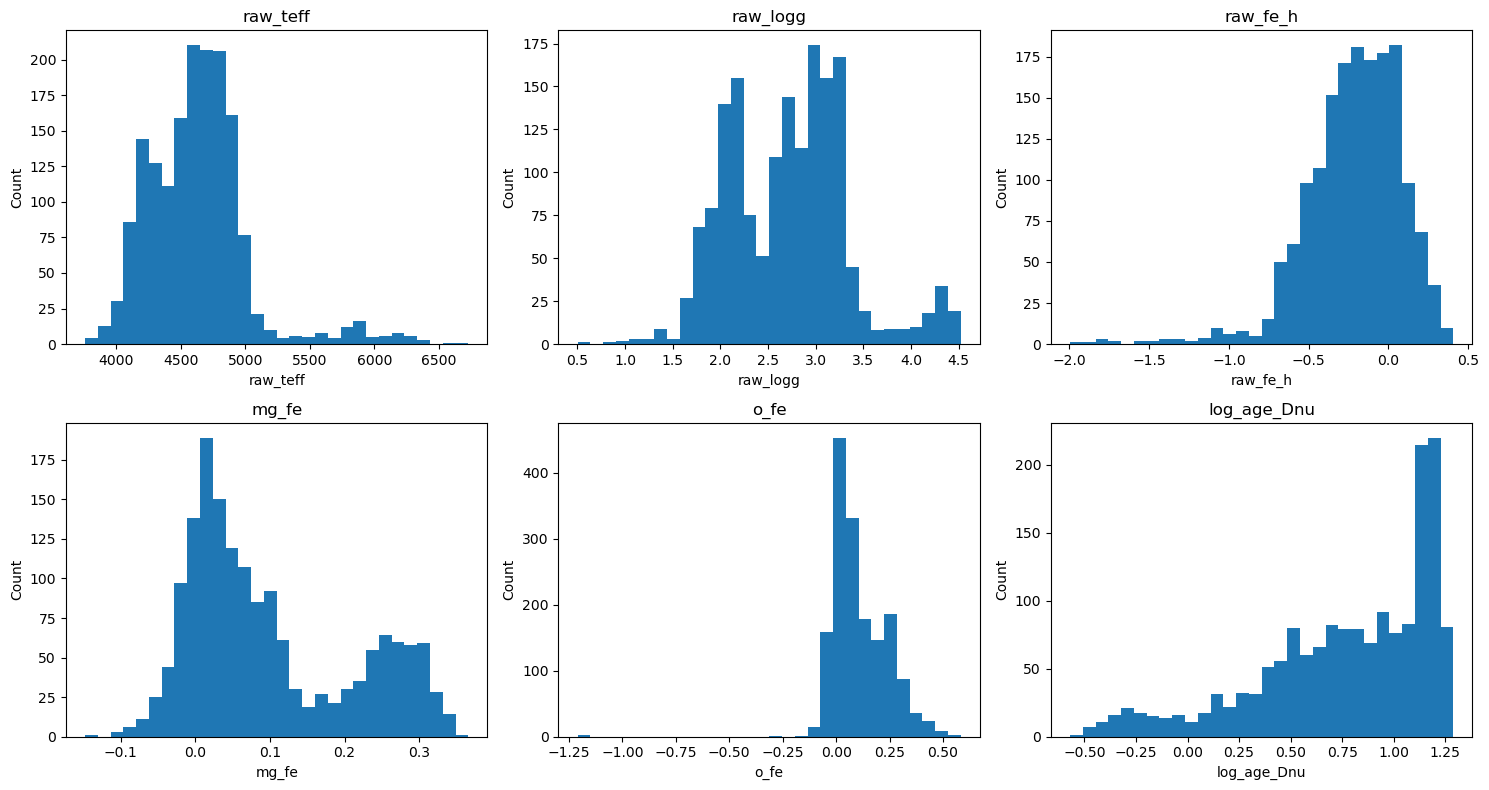

In [148]:
# Automatically plot all label columns as histograms in subplots

num_labels = len(labels.columns)
ncols = 3
nrows = (num_labels + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.flatten()

for i, col in enumerate(labels.columns):
    axes[i].hist(labels[col].dropna(), bins=30)
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

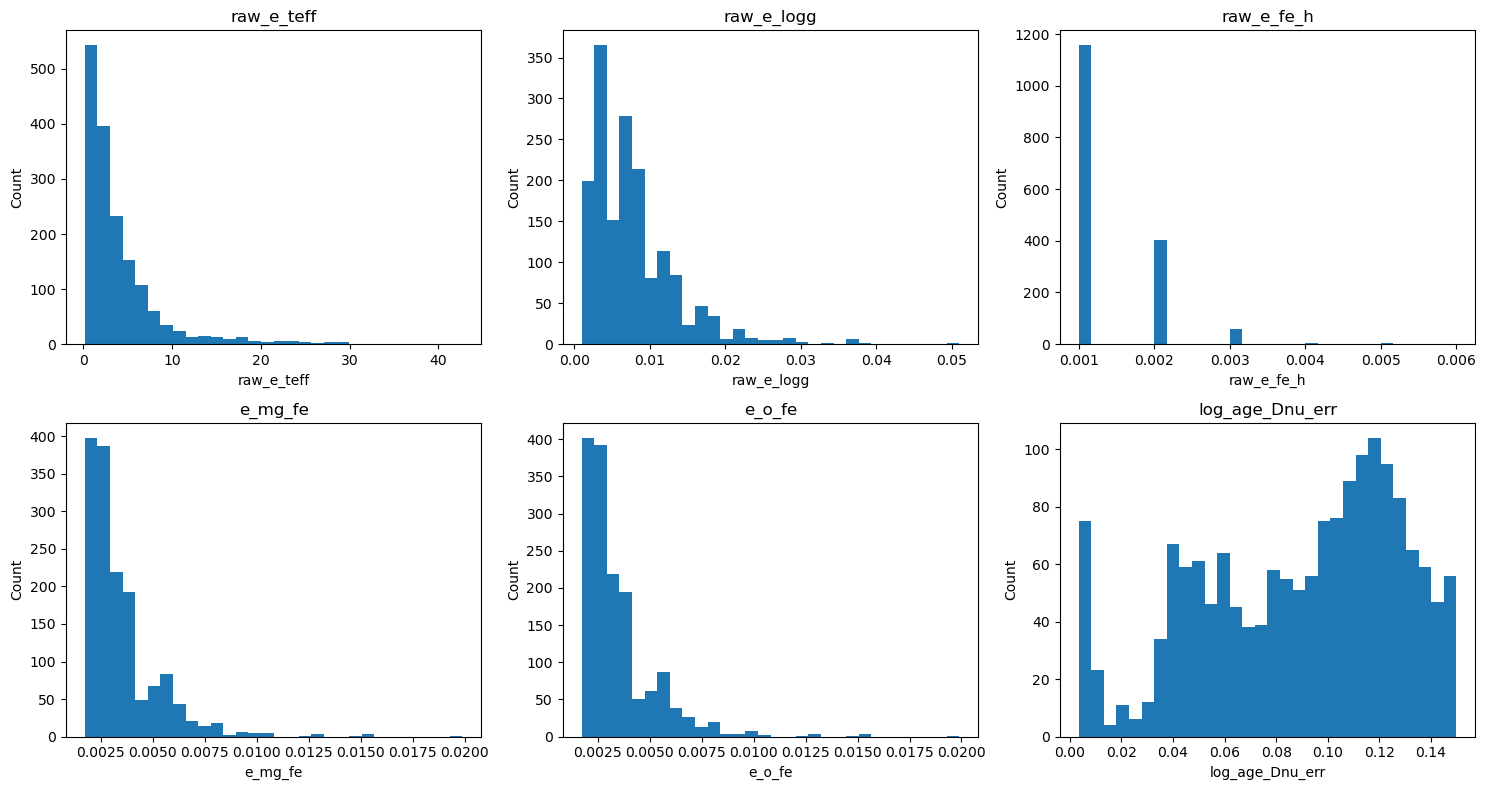

In [149]:
# Automatically plot all label columns as histograms in subplots

num_labels = len(labels.columns)
ncols = 3
nrows = (num_labels + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.flatten()

for i, col in enumerate(labels.columns):
    if col.startswith('raw_'):
        col = col.replace('raw_', 'raw_e_')
    elif col == 'log_age_Dnu':
        col = 'log_age_Dnu_err'
    else:
        col = 'e_' + col
    axes[i].hist(spectra[col].dropna(), bins=30)
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [150]:
# Integer continuum-pixel indices. Keep only those valid for this grid.
continuum_pixels = np.loadtxt(SRC / "bulge-ages-and-orbits/data/continuum.list", dtype=int, comments="#")
continuum_pixels = continuum_pixels[continuum_pixels < dispersion.size]
APOGEE_REGIONS = ([15090, 15822], [15823, 16451], [16452, 16971])

In [151]:
import jax.numpy as jnp
dispersion = jnp.array(dispersion)
flux = jnp.array(flux)
ivar = jnp.array(ivar)
continuum_pixels = jnp.array(continuum_pixels)
APOGEE_REGIONS = [jnp.array(r) for r in APOGEE_REGIONS]

In [152]:
# NB: output is named `continuum_fit` so it doesn't shadow the imported
# `continuum` module (otherwise re-running this cell would fail).
normalized_flux, normalized_ivar, continuum_fit, metadata = continuum.normalize(
    dispersion,          # (n_pixels,) APOGEE wavelength grid
    flux,                # (n_stars, n_pixels)
    ivar,                # inverse variance, same shape
    continuum_pixels,
    L=1400, order=3,
    regions=APOGEE_REGIONS,
)

# Quick check: were the spectra already normalized, or did we just normalize them?
good = ivar > 0
print("median raw flux on good pixels:    ", np.median(flux[good]))
print("median normalized flux (should ~1):", np.median(normalized_flux[good]))

Normalizing:   0%|          | 0/3 [00:00<?, ?region/s]

median raw flux on good pixels:     1427.52734375
median normalized flux (should ~1): 0.9838338606157843


## Build, train, and test a CannonModel

Split into training / validation sets (dropping rows with non-finite labels),
fit a quadratic model on the training set, then predict labels for the
validation set and compare against the ASPCAP values.

In [153]:
list(labels.columns)

['raw_teff', 'raw_logg', 'raw_fe_h', 'mg_fe', 'o_fe', 'log_age_Dnu']

In [154]:
LABEL_NAMES = list(labels.columns)

# Drop stars with any non-finite label -- NaNs would break the training fit.
finite = np.isfinite(labels[LABEL_NAMES].values).all(axis=1)

# 80% training / 20% validation split.
rng = np.random.RandomState(888)
q = rng.randint(0, 10, len(spectra))
train_set = finite & (q > 1)
validate_set = finite & (q <= 1)
print(f"{train_set.sum()} training, {validate_set.sum()} validation stars ",
      f"({(~finite).sum()} dropped for non-finite labels)")

1293 training, 334 validation stars  (24 dropped for non-finite labels)


In [ ]:
# Quadratic (order=2) polynomial vectorizer -- the standard Cannon choice.
# order=4 with 8 labels gave 495 coefficients per pixel fit from ~2000 stars,
# which badly overfits; order=2 gives 45 terms and needs little to no
# regularization. If you reintroduce regularization, tune it against the
# validation scatter rather than fixing it by hand.
vectorizer = tc.vectorizer.PolynomialVectorizer(label_names=LABEL_NAMES, order=2)
model = tc.CannonModel(
    labels[train_set],            # DataFrame with the label columns
    normalized_flux[train_set],
    normalized_ivar[train_set],
    vectorizer,                   # positional, required
    dispersion=dispersion,
    regularization=0)

print(model)
# get_human_readable_label_vector() already returns a joined string.
print("Vectorizer terms:", vectorizer.get_human_readable_label_vector())

# Train (fits theta + scatter s2 at every pixel). `threads` is deprecated/ignored
# now -- the fit is vectorized with jax.vmap.
theta, s2, train_meta = model.train()
print("trained:", model.is_trained, "| theta shape:", np.asarray(theta).shape)

2026-07-07 10:05:21,648 [INFO] Training 6-label CannonModel with 1293 stars and 8575 pixels/star
INFO:thecannon.model:Training 6-label CannonModel with 1293 stars and 8575 pixels/star


<thecannon.model.CannonModel of 6 labels with a training set of 1293 stars each with 8575 pixels>
Vectorizer terms: 1 + raw_teff + raw_logg + raw_fe_h + mg_fe + o_fe + log_age_Dnu + raw_teff^2 + raw_logg*raw_teff + raw_fe_h*raw_teff + mg_fe*raw_teff + o_fe*raw_teff + log_age_Dnu*raw_teff + raw_logg^2 + raw_fe_h*raw_logg + mg_fe*raw_logg + o_fe*raw_logg + log_age_Dnu*raw_logg + raw_fe_h^2 + mg_fe*raw_fe_h + o_fe*raw_fe_h + log_age_Dnu*raw_fe_h + mg_fe^2 + mg_fe*o_fe + log_age_Dnu*mg_fe + o_fe^2 + log_age_Dnu*o_fe + log_age_Dnu^2


Training:   0%|          | 0/17 [00:00<?, ?it/s]

trained: True | theta shape: (8575, 28)


In [156]:
# Predict labels for the validation set (the "test" step). Returns
# (labels, covariance, metadata). Note: it's .test(), not .fit().
val_labels, val_cov, val_meta = model.test(
    normalized_flux[validate_set], normalized_ivar[validate_set], batch_size=32)
val_labels = np.asarray(val_labels)
truth = labels[validate_set].values
print("predicted label array shape:", val_labels.shape)

Testing:   0%|          | 0/11 [00:00<?, ?it/s]

predicted label array shape: (334, 6)


In [157]:
# Flag (but do NOT remove) validation outliers, so the quoted statistics stay
# honest: a star is an outlier if its residual in any label is more than
# 3 robust-sigma (1.48*MAD) from the median residual, or if any prediction is
# non-finite. Outliers are shown in grey in the one-to-one plot below but are
# still included in the bias/scatter statistics.
resids = val_labels - truth
med = np.nanmedian(resids, axis=0)
robust_sigma = 1.4826 * np.nanmedian(np.abs(resids - med), axis=0)
finite_pred = np.all(np.isfinite(val_labels), axis=1)
outlier = ~(np.all(np.abs(resids - med) < 3 * robust_sigma, axis=1) & finite_pred)
print(f"{outlier.sum()} of {len(outlier)} validation stars flagged as outliers "
      "(plotted in grey; still counted in the statistics)")

65 of 334 validation stars flagged as outliers (plotted in grey; still counted in the statistics)


In [158]:
# Flag (but do not remove) physically unreasonable age predictions:
# outside 0-20 Gyr (log_age_Dnu is log10 of the age in Gyr).
if 'log_age_Dnu' in LABEL_NAMES:
    age_idx = LABEL_NAMES.index('log_age_Dnu')
    age_gyr = 10**val_labels[:, age_idx]
    unphysical = ~((age_gyr > 0) & (age_gyr < 20))
    print(f"{unphysical.sum()} predicted ages fall outside 0-20 Gyr")
    outlier |= unphysical

5 predicted ages fall outside 0-20 Gyr


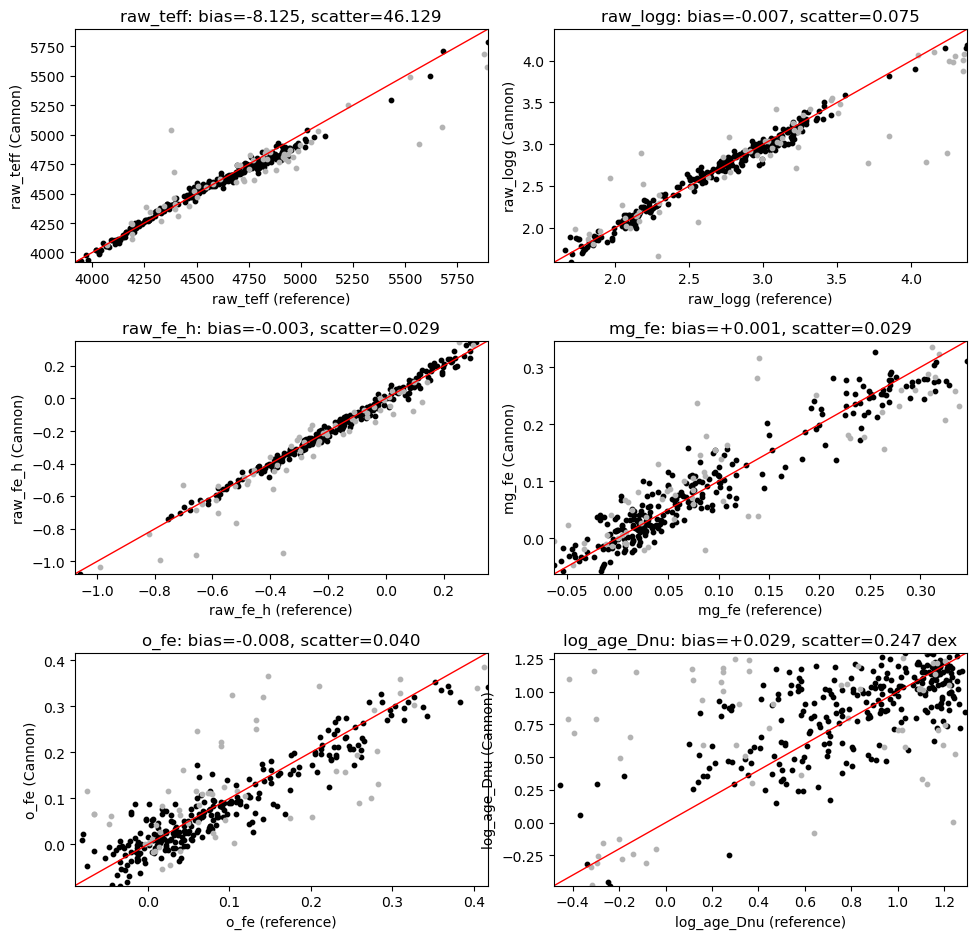

In [159]:
# One-to-one comparison of Cannon-predicted vs ASPCAP/seismic labels on the
# FULL validation set. No sigma clipping: outliers are shown in grey rather
# than removed, and the quoted bias/scatter are robust statistics (median and
# 1.48*MAD) over all finite points. Age is compared in log space (dex), where
# the scatter is not dominated by the oldest stars.
nrows = (len(LABEL_NAMES) + 1) // 2
fig, axes = plt.subplots(nrows, 2, figsize=(10, 2.5 * nrows + 2))
axes = axes.ravel()
for i, name in enumerate(LABEL_NAMES):
    ax = axes[i]
    x, y = truth[:, i], val_labels[:, i]
    ok = np.isfinite(x) & np.isfinite(y)
    d = y[ok] - x[ok]
    bias = np.median(d)
    scatter = 1.4826 * np.median(np.abs(d - bias))
    ax.scatter(x[ok & ~outlier], y[ok & ~outlier], facecolor="k", s=10)
    ax.scatter(x[ok & outlier], y[ok & outlier], facecolor="0.7", s=10)
    # Axis limits from the non-outlier points; grey outliers may fall outside.
    xg, yg = x[ok & ~outlier], y[ok & ~outlier]
    lims = [min(xg.min(), yg.min()), max(xg.max(), yg.max())]
    ax.plot(lims, lims, "-", color="r", lw=1)           # 1:1 line
    ax.set_xlim(lims); ax.set_ylim(lims)
    unit = " dex" if name == "log_age_Dnu" else ""
    ax.set_xlabel(f"{name} (reference)")
    ax.set_ylabel(f"{name} (Cannon)")
    ax.set_title(f"{name}: bias={bias:+.3f}, scatter={scatter:.3f}{unit}")
for ax in axes[len(LABEL_NAMES):]:
    ax.set_visible(False)
fig.tight_layout()

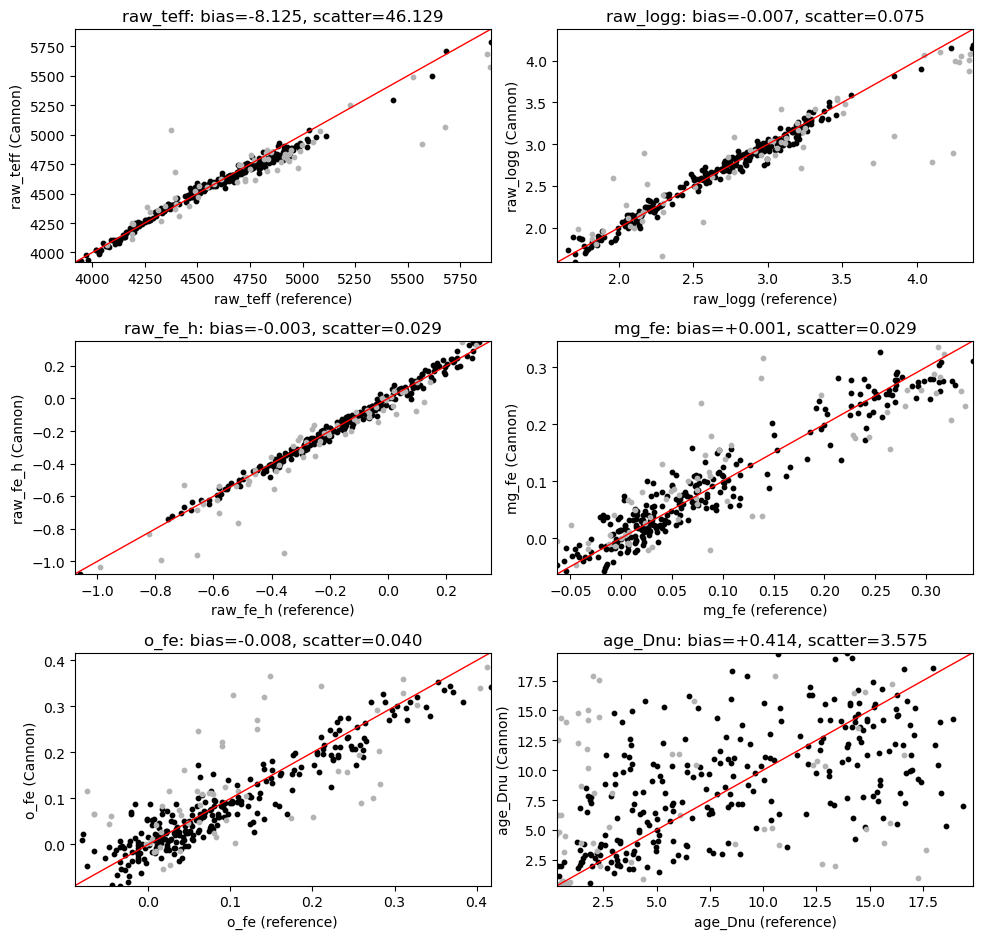

In [ ]:
nrows = (len(LABEL_NAMES) + 1) // 2
fig, axes = plt.subplots(nrows, 2, figsize=(10, 2.5 * nrows + 2))
axes = axes.ravel()
for i, name in enumerate(LABEL_NAMES):
    ax = axes[i]
    x, y = truth[:, i], val_labels[:, i]
    ok = np.isfinite(x) & np.isfinite(y)
    if name == 'log_age_Dnu':
        name = 'age_Dnu'
        x = 10**x
        y = 10**y
    d = y[ok] - x[ok]
    bias = np.median(d)
    scatter = 1.4826 * np.median(np.abs(d - bias))
    ax.scatter(x[ok & ~outlier], y[ok & ~outlier], facecolor="k", s=10)
    ax.scatter(x[ok & outlier], y[ok & outlier], facecolor="0.7", s=10)
    # Axis limits from the non-outlier points; grey outliers may fall outside.
    xg, yg = x[ok & ~outlier], y[ok & ~outlier]
    lims = [min(xg.min(), yg.min()), max(xg.max(), yg.max())]
    ax.plot(lims, lims, "-", color="r", lw=1)           # 1:1 line
    ax.set_xlim(lims); ax.set_ylim(lims)
    #unit = " dex" if name == "log_age_Dnu" else ""
    unit = ""
    ax.set_xlabel(f"{name} (reference)")
    ax.set_ylabel(f"{name} (Cannon)")
    ax.set_title(f"{name}: bias={bias:+.3f}, scatter={scatter:.3f}{unit}")
for ax in axes[len(LABEL_NAMES):]:
    ax.set_visible(False)
fig.tight_layout()

In [162]:
10**0.247

1.7660378206861644

In [163]:
# Save the trained model to disk
model.write("scr_mk27/trained_cannon_model_rgb.pkl", overwrite=True)